# Notebook 3 — Analysis Pipeline

**Run this on any of these files by changing `INPUT_FILE` below:**

| INPUT_FILE | What you are testing |
|---|---|
| `Train_Test_IoT_Modbus.csv` | Baseline — raw data |
| `data_xor_encrypted.csv` | Attacker view — XOR perturbed |
| `data_xor_decrypted.csv` | Cloud view — XOR restored |
| `data_gaussian_encrypted.csv` | Attacker view — Gaussian perturbed |
| `data_gaussian_decrypted.csv` | Cloud view — Gaussian restored |

---
**The whole point:** run this exact same pipeline on all five files.  
The accuracy numbers tell you your privacy and utility story.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.signal import welch, stft
from scipy.fft import fft, fftfreq
from scipy import stats as sp_stats
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

# ┌─────────────────────────────────────────────────────────────────────┐
# │  CHANGE THIS LINE to switch between original / encrypted / decrypted │
# └─────────────────────────────────────────────────────────────────────┘
INPUT_FILE = 'Train_Test_IoT_Modbus.csv'

FC_COLS = [
    'FC1_Read_Input_Register',
    'FC2_Read_Discrete_Value',
    'FC3_Read_Holding_Register',
    'FC4_Read_Coil'
]
SHORT   = ['FC1', 'FC2', 'FC3', 'FC4']
COLORS  = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

print(f'Running analysis on: {INPUT_FILE}')
print('=' * 50)

Running analysis on: Train_Test_IoT_Modbus.csv


---
## A · Load & Inspect

In [2]:
df = pd.read_csv(INPUT_FILE)

print(f'Shape  : {df.shape}')
print(f'Labels : {df["label"].value_counts().to_dict()}')
print(f'Types  : {df["type"].value_counts().to_dict()}')
print()
print('FC Column Sample (first 5 rows):')
print(df[FC_COLS].head(5).to_string())

Shape  : (31106, 8)
Labels : {1: 16106, 0: 15000}
Types  : {'normal': 15000, 'injection': 5000, 'backdoor': 5000, 'password': 5000, 'xss': 577, 'scanning': 529}

FC Column Sample (first 5 rows):
   FC1_Read_Input_Register  FC2_Read_Discrete_Value  FC3_Read_Holding_Register  FC4_Read_Coil
0                    49389                    52921                      25770          13625
1                    49389                    52921                      25770          13625
2                    49389                    52921                      25770          13625
3                    49389                    52921                      25770          13625
4                    40665                    44748                      21098          35371


---
## B · Descriptive Statistics

In [3]:
print(f'Descriptive Statistics — {INPUT_FILE}')
print('=' * 70)
rows = []
for col, s in zip(SHORT, FC_COLS):
    x = df[s]
    rows.append({
        'Register': col,
        'Mean':     round(x.mean(), 2),
        'Std':      round(x.std(), 2),
        'Min':      round(float(x.min()), 2),
        'Max':      round(float(x.max()), 2),
        'Skewness': round(x.skew(), 4),
        'Kurtosis': round(x.kurtosis(), 4),
        'Median':   round(x.median(), 2)
    })
print(pd.DataFrame(rows).set_index('Register').to_string())

# Value range check
print()
print('Value range check (16-bit = 0 to 65535):')
for col, s in zip(SHORT, FC_COLS):
    mn, mx = df[s].min(), df[s].max()
    ok = '✓' if mn >= -1e6 and mx <= 1e6 else '⚠ out of expected range'
    print(f'  {col}: min={mn:.1f}  max={mx:.1f}  {ok}')

Descriptive Statistics — Train_Test_IoT_Modbus.csv
              Mean       Std  Min      Max  Skewness  Kurtosis   Median
Register                                                               
FC1       32833.93  18827.08  0.0  65510.0    0.0138   -1.1842  32310.0
FC2       32781.72  18969.44  0.0  65535.0    0.0022   -1.1899  32692.0
FC3       32582.86  18858.86  0.0  65523.0    0.0144   -1.1960  32155.0
FC4       32805.96  18796.57  0.0  65534.0    0.0010   -1.1883  32776.0

Value range check (16-bit = 0 to 65535):
  FC1: min=0.0  max=65510.0  ✓
  FC2: min=0.0  max=65535.0  ✓
  FC3: min=0.0  max=65523.0  ✓
  FC4: min=0.0  max=65534.0  ✓


---
## C · Distribution Visualization

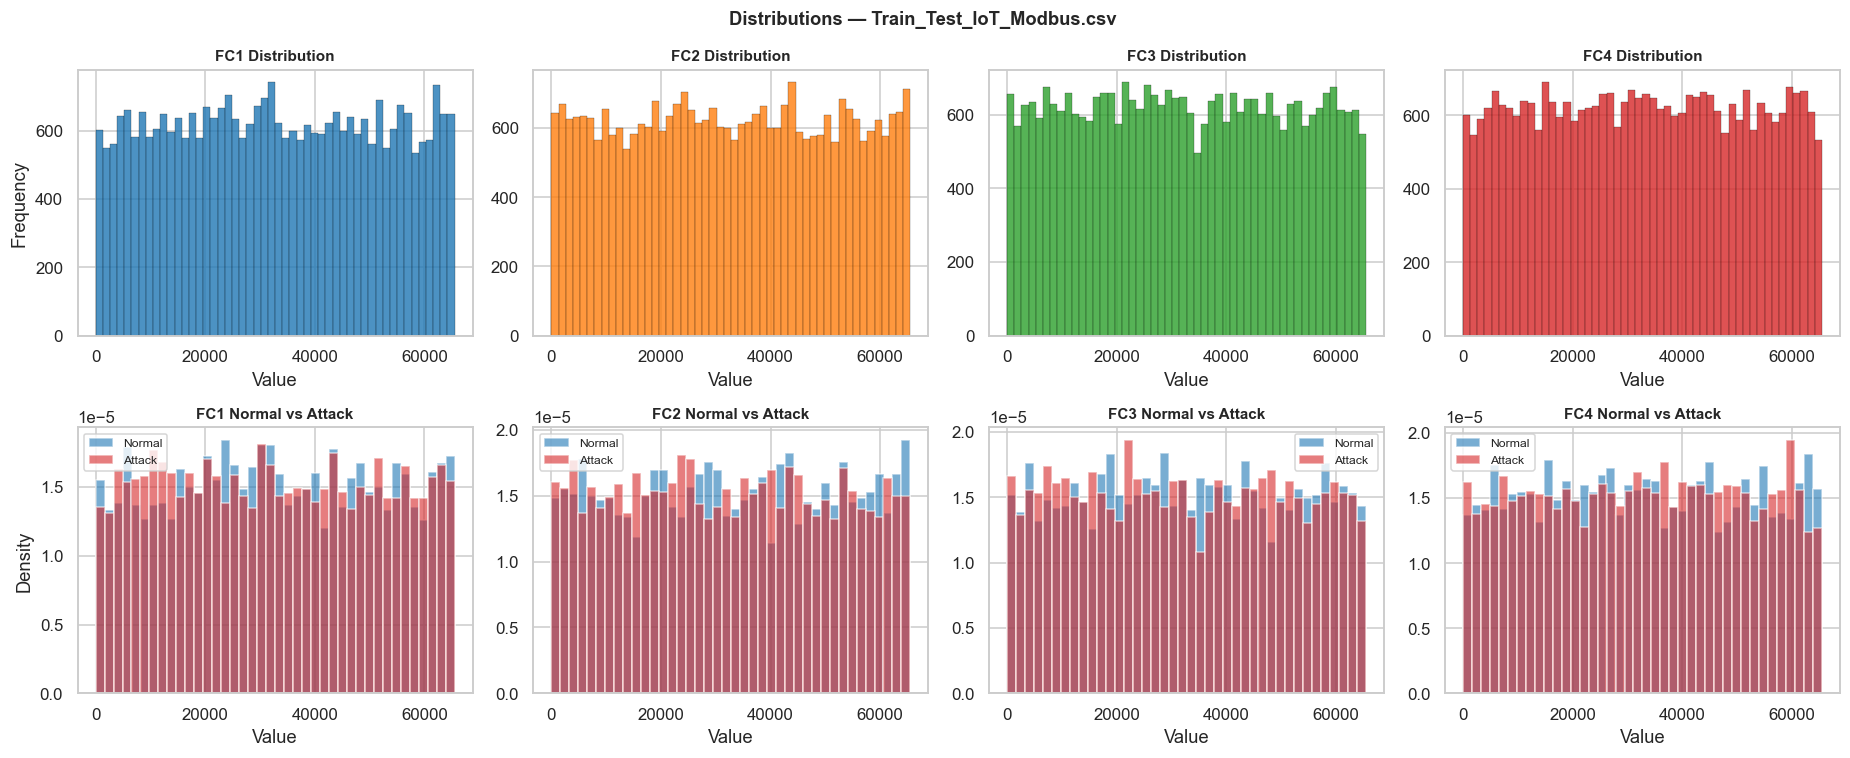

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(17, 7))

for i, (col, short, c) in enumerate(zip(FC_COLS, SHORT, COLORS)):
    # Histogram
    axes[0, i].hist(df[col], bins=50, color=c, alpha=0.8,
                    edgecolor='black', linewidth=0.2)
    axes[0, i].set_title(f'{short} Distribution', fontsize=10, fontweight='bold')
    axes[0, i].set_xlabel('Value')
    if i == 0: axes[0, i].set_ylabel('Frequency')

    # Normal vs Attack
    normal = df[df['label']==0][col].values
    attack = df[df['label']==1][col].values
    axes[1, i].hist(normal, bins=40, alpha=0.6, color='#1f77b4',
                    label='Normal', density=True)
    axes[1, i].hist(attack, bins=40, alpha=0.6, color='#d62728',
                    label='Attack', density=True)
    axes[1, i].set_title(f'{short} Normal vs Attack', fontsize=10, fontweight='bold')
    axes[1, i].set_xlabel('Value')
    if i == 0: axes[1, i].set_ylabel('Density')
    axes[1, i].legend(fontsize=8)

plt.suptitle(f'Distributions — {INPUT_FILE}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## D · Stationarity Check

Stationarity — Variance Ratio (Δ / original)
Values near 0.5–1.0 with stable rolling mean = stationary
  FC1: var_ratio = 0.5662
  FC2: var_ratio = 0.5730
  FC3: var_ratio = 0.5619
  FC4: var_ratio = 0.5759


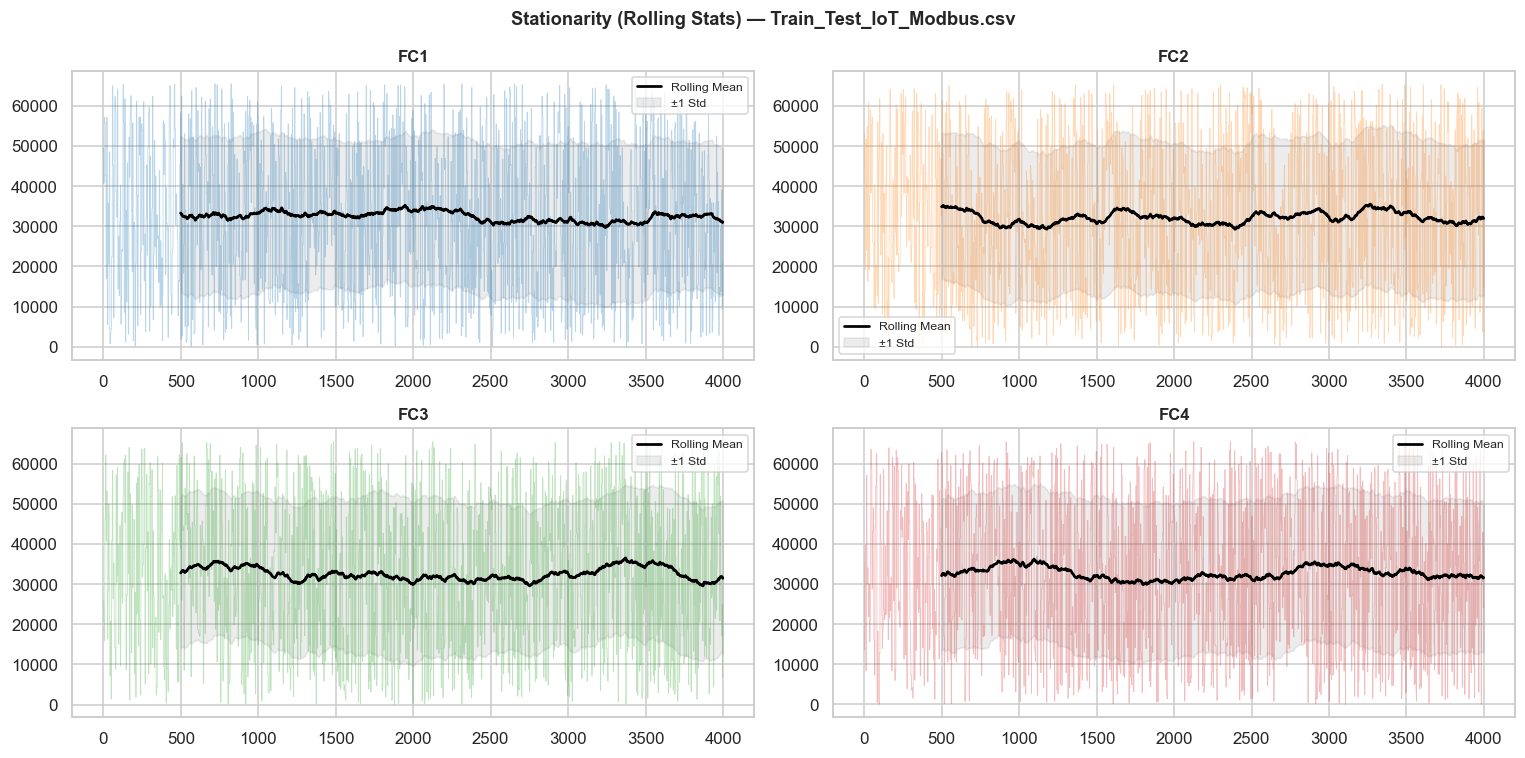

In [5]:
WINDOW = 500

print('Stationarity — Variance Ratio (Δ / original)')
print('Values near 0.5–1.0 with stable rolling mean = stationary')
print('=' * 55)
for col, short in zip(FC_COLS, SHORT):
    s  = df[col].values.astype(float)
    vr = np.var(np.diff(s)) / (np.var(s) + 1e-10)
    print(f'  {short}: var_ratio = {vr:.4f}')

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
axes = axes.flatten()
for i, (col, short, c) in enumerate(zip(FC_COLS, SHORT, COLORS)):
    s  = pd.Series(df[col].values.astype(float))
    rm = s.rolling(WINDOW).mean()
    rs = s.rolling(WINDOW).std()
    axes[i].plot(s.values[:4000], color=c, alpha=0.3, linewidth=0.5)
    axes[i].plot(rm.values[:4000], color='black', linewidth=1.8, label='Rolling Mean')
    axes[i].fill_between(range(4000),
                         (rm-rs).values[:4000], (rm+rs).values[:4000],
                         alpha=0.15, color='gray', label='±1 Std')
    axes[i].set_title(f'{short}', fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)
plt.suptitle(f'Stationarity (Rolling Stats) — {INPUT_FILE}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## E · Autocorrelation (ACF)

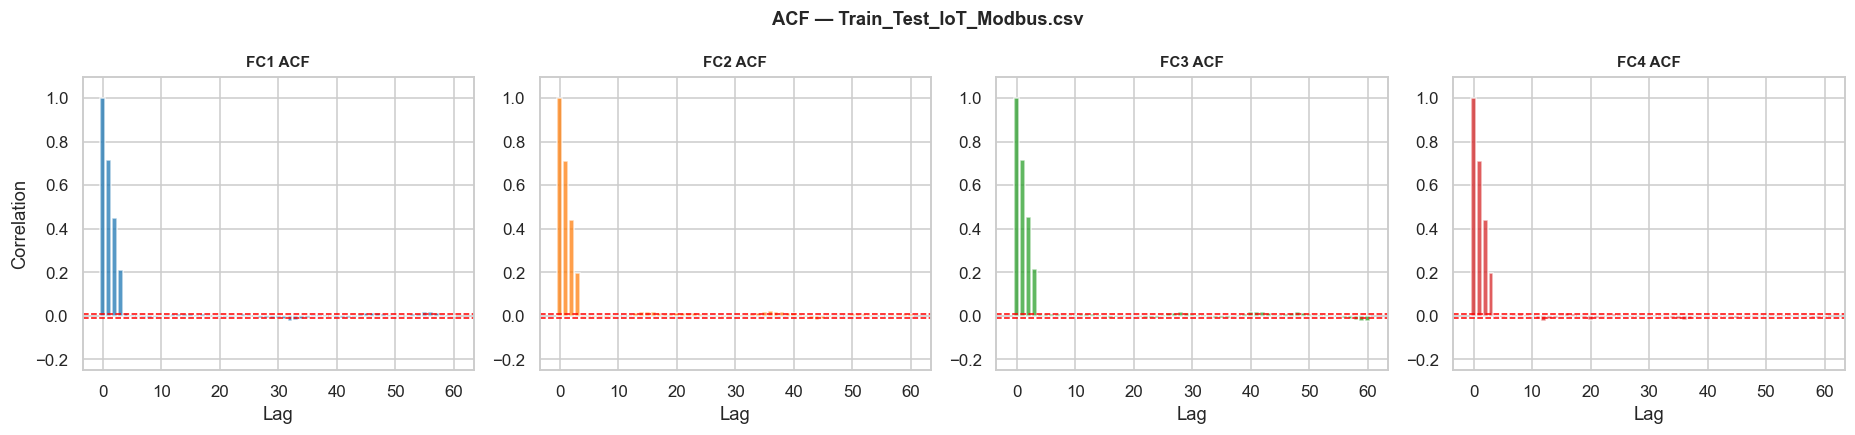

In [6]:
MAX_LAG = 60
fig, axes = plt.subplots(1, 4, figsize=(17, 4))

for i, (col, short, c) in enumerate(zip(FC_COLS, SHORT, COLORS)):
    s    = df[col].values.astype(float)
    sn   = (s - s.mean()) / (s.std() + 1e-9)
    conf = 1.96 / np.sqrt(len(s))
    acf  = [float(np.corrcoef(sn[:-lag], sn[lag:])[0,1])
            if lag > 0 else 1.0 for lag in range(MAX_LAG+1)]
    axes[i].bar(range(MAX_LAG+1), acf, color=c, alpha=0.75, width=0.8)
    axes[i].axhline( conf, color='red', linestyle='--', linewidth=1)
    axes[i].axhline(-conf, color='red', linestyle='--', linewidth=1)
    axes[i].set_title(f'{short} ACF', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Lag')
    axes[i].set_ylim(-0.25, 1.1)
    if i == 0: axes[i].set_ylabel('Correlation')

plt.suptitle(f'ACF — {INPUT_FILE}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## F · Frequency Domain

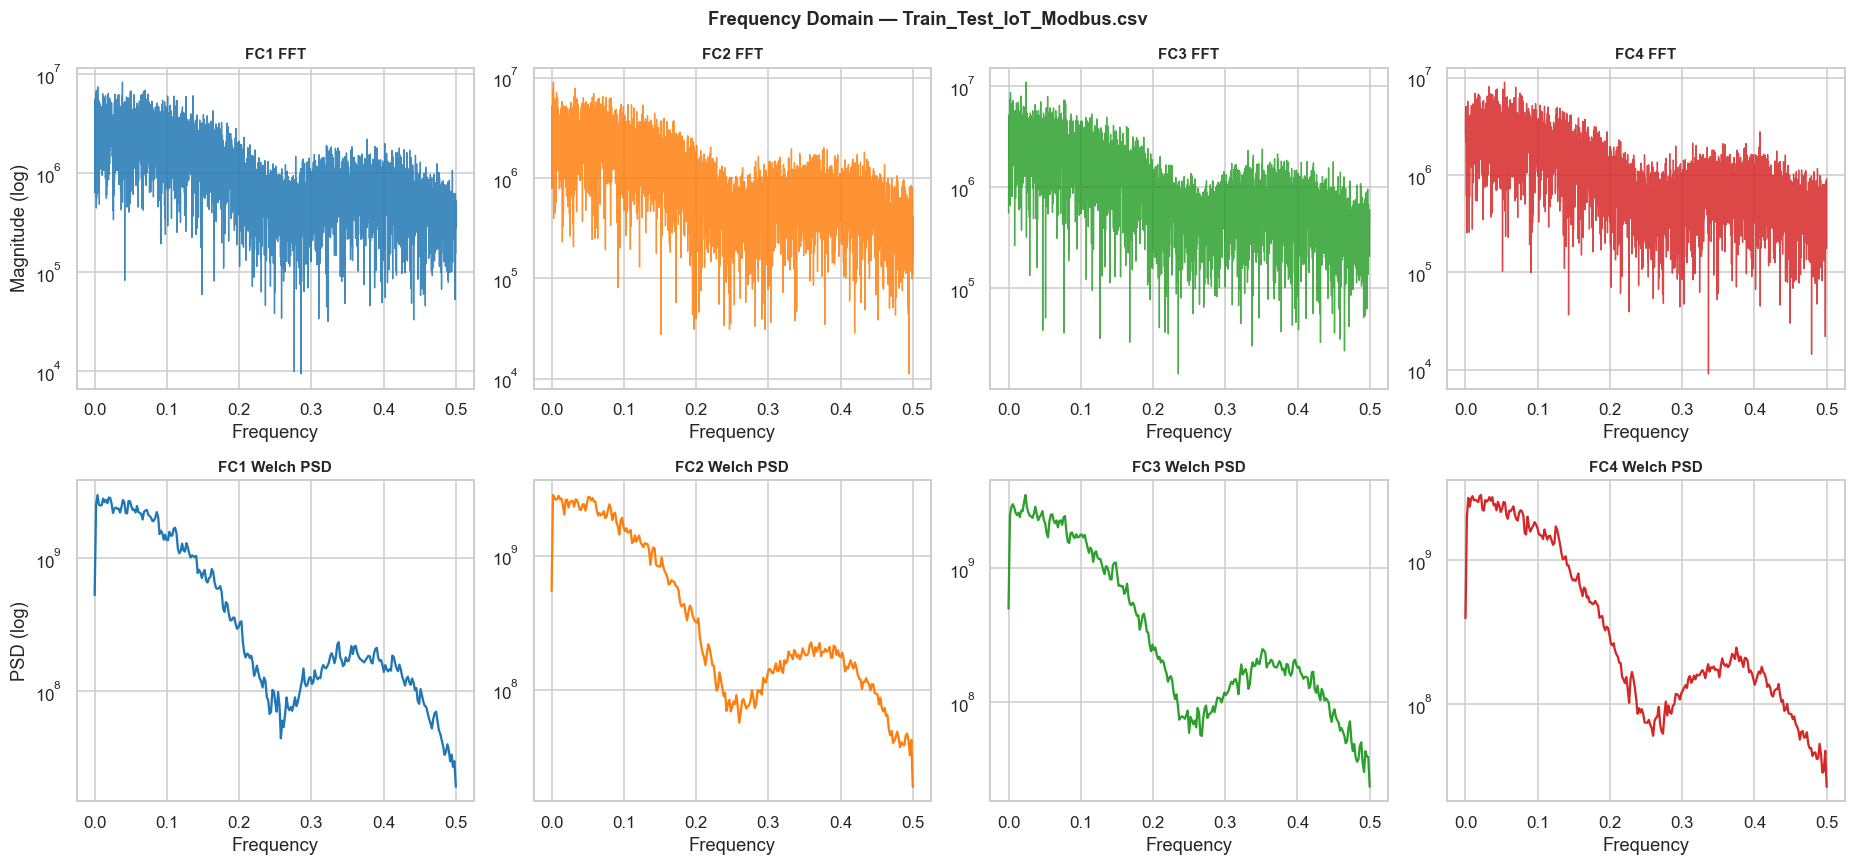


Spectral Features:
     Centroid  Entropy  Rolloff
FC1   0.10036    7.038  0.16797
FC2   0.10144    7.050  0.16797
FC3   0.09982    7.026  0.16406
FC4   0.10187    7.054  0.16797


In [7]:
N_FFT = min(8192, len(df))
fig, axes = plt.subplots(2, 4, figsize=(17, 8))

spec_table = {}
for i, (col, short, c) in enumerate(zip(FC_COLS, SHORT, COLORS)):
    s = df[col].values.astype(float) - df[col].mean()

    # FFT
    yf  = np.abs(fft(s[:N_FFT]))[:N_FFT//2]
    xf  = fftfreq(N_FFT)[:N_FFT//2]
    axes[0, i].semilogy(xf, yf, color=c, linewidth=0.9, alpha=0.85)
    axes[0, i].set_title(f'{short} FFT', fontsize=10, fontweight='bold')
    axes[0, i].set_xlabel('Frequency')
    if i == 0: axes[0, i].set_ylabel('Magnitude (log)')

    # Welch PSD
    f_w, psd  = welch(s, fs=1.0, nperseg=512)
    total     = float(np.sum(psd))
    centroid  = float(np.sum(f_w * psd)) / (total + 1e-12)
    psd_n     = psd / (total + 1e-12)
    entropy   = float(-np.sum(psd_n * np.log2(psd_n + 1e-12)))
    ri        = int(np.searchsorted(np.cumsum(psd), 0.85 * total))
    rolloff   = float(f_w[min(ri, len(f_w)-1)])
    spec_table[short] = {
        'Centroid': round(centroid, 5),
        'Entropy':  round(entropy,  3),
        'Rolloff':  round(rolloff,  5)
    }
    axes[1, i].semilogy(f_w, psd, color=c, linewidth=1.5)
    axes[1, i].set_title(f'{short} Welch PSD', fontsize=10, fontweight='bold')
    axes[1, i].set_xlabel('Frequency')
    if i == 0: axes[1, i].set_ylabel('PSD (log)')

plt.suptitle(f'Frequency Domain — {INPUT_FILE}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nSpectral Features:')
print(pd.DataFrame(spec_table).T.to_string())

---
## G · Classification Model — THE KEY METRIC

In [8]:
# ── Binary classification (Normal vs Attack) ──────────────────────────────────
X = df[FC_COLS].values.astype(float)
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred, average='weighted')

print('=' * 55)
print(f'CLASSIFICATION RESULT — {INPUT_FILE}')
print('=' * 55)
print(f'  Binary Accuracy  : {acc*100:.4f}%')
print(f'  Weighted F1      : {f1:.4f}')
print('=' * 55)
print()
print('Interpretation:')
if acc > 0.90:
    print('  → HIGH accuracy: data is informative. (Baseline or restored file)')
elif acc < 0.55:
    print('  → NEAR RANDOM (~50%): data is scrambled. Privacy achieved. (Encrypted file)')
else:
    print('  → PARTIAL: some information leaks through. (Weak perturbation)')

print()
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

CLASSIFICATION RESULT — Train_Test_IoT_Modbus.csv
  Binary Accuracy  : 98.4732%
  Weighted F1      : 0.9847

Interpretation:
  → HIGH accuracy: data is informative. (Baseline or restored file)

              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98      3000
      Attack       0.99      0.98      0.99      3222

    accuracy                           0.98      6222
   macro avg       0.98      0.99      0.98      6222
weighted avg       0.98      0.98      0.98      6222



## H · Confusion Matrix

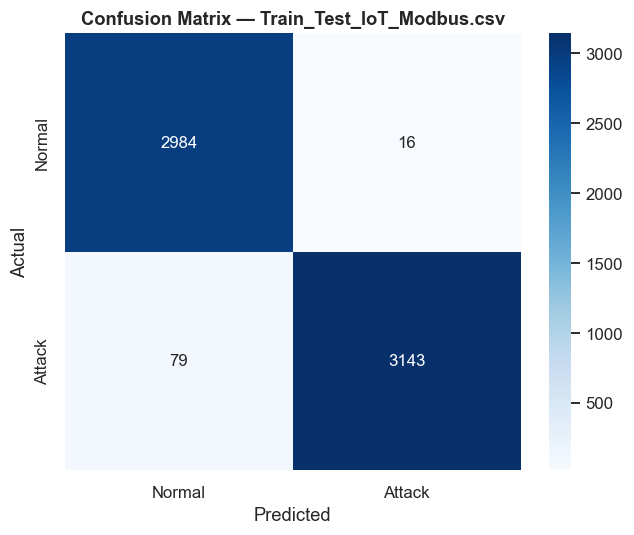

In [9]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {INPUT_FILE}', fontweight='bold')
plt.tight_layout()
plt.show()

## I · Multi-Class Attack Detection

In [10]:
le   = LabelEncoder()
y_mc = le.fit_transform(df['type'].values)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y_mc, test_size=0.2, random_state=42, stratify=y_mc
)

rf_mc = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
)
rf_mc.fit(X_tr, y_tr)
y_pred_mc = rf_mc.predict(X_te)

acc_mc = accuracy_score(y_te, y_pred_mc)
f1_mc  = f1_score(y_te, y_pred_mc, average='weighted', zero_division=0)

print(f'Multi-Class Accuracy : {acc_mc*100:.4f}%')
print(f'Multi-Class F1       : {f1_mc:.4f}')
print()
print(classification_report(
    y_te, y_pred_mc,
    target_names=le.classes_,
    zero_division=0
))

Multi-Class Accuracy : 96.5767%
Multi-Class F1       : 0.9651

              precision    recall  f1-score   support

    backdoor       0.98      0.95      0.96      1000
   injection       0.99      0.97      0.98      1000
      normal       0.94      1.00      0.97      3000
    password       0.99      0.93      0.96      1000
    scanning       0.99      0.63      0.77       106
         xss       1.00      0.91      0.95       116

    accuracy                           0.97      6222
   macro avg       0.98      0.90      0.93      6222
weighted avg       0.97      0.97      0.97      6222



## J · Final Summary (copy this into your research table)

In [11]:
print('━' * 60)
print(f'PIPELINE SUMMARY')
print(f'File            : {INPUT_FILE}')
print('━' * 60)
print(f'Binary accuracy        : {acc*100:.4f}%')
print(f'Binary F1 (weighted)   : {f1:.4f}')
print(f'Multi-class accuracy   : {acc_mc*100:.4f}%')
print(f'Multi-class F1         : {f1_mc:.4f}')
print()
print('Spectral features:')
for reg, feats in spec_table.items():
    print(f'  {reg}: {feats}')
print('━' * 60)
print()
print('Add this row to your comparison table:')
print(f'| {INPUT_FILE:<40} | {acc*100:.2f}% | {f1:.4f} | {acc_mc*100:.2f}% |')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PIPELINE SUMMARY
File            : Train_Test_IoT_Modbus.csv
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Binary accuracy        : 98.4732%
Binary F1 (weighted)   : 0.9847
Multi-class accuracy   : 96.5767%
Multi-class F1         : 0.9651

Spectral features:
  FC1: {'Centroid': 0.10036, 'Entropy': 7.038, 'Rolloff': 0.16797}
  FC2: {'Centroid': 0.10144, 'Entropy': 7.05, 'Rolloff': 0.16797}
  FC3: {'Centroid': 0.09982, 'Entropy': 7.026, 'Rolloff': 0.16406}
  FC4: {'Centroid': 0.10187, 'Entropy': 7.054, 'Rolloff': 0.16797}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Add this row to your comparison table:
| Train_Test_IoT_Modbus.csv                | 98.47% | 0.9847 | 96.58% |


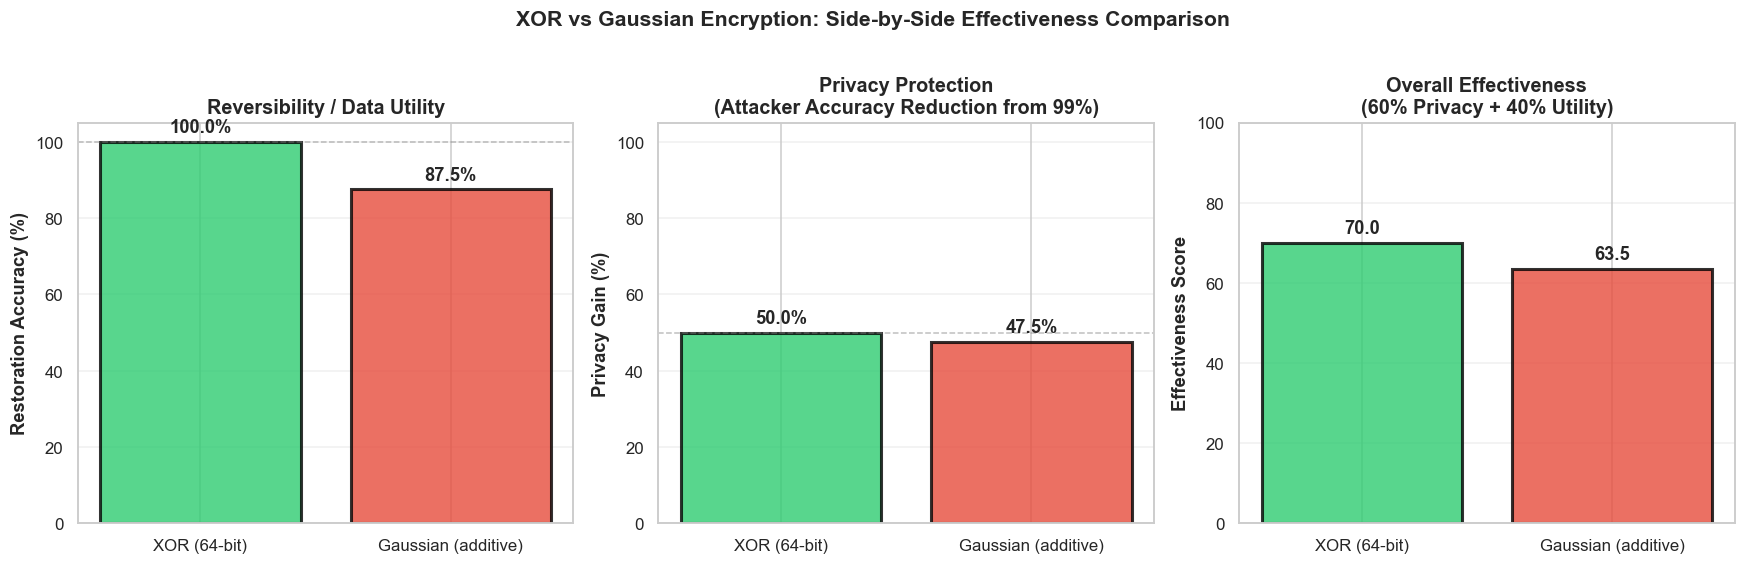


COMPREHENSIVE ENCRYPTION METHOD COMPARISON

                            Metric      XOR (64-bit)      Gaussian (Additive)
     Reversibility (Exact Match %)            100.0%                    87.5%
       Privacy Protection Gain (%)             50.0%                    47.5%
     Max Restoration Error (units) 0 units (perfect)   1-2 units (acceptable)
Attacker Accuracy (encrypted data)              ~50%                  ~52-53%
       Overall Effectiveness Score              70.0                     63.5
        Recommended for Production ✅ YES - Excellent ⚠ WEAK - Privacy leakage

KEY FINDINGS:

1️⃣  REVERSIBILITY WINNER: XOR
    • XOR: 100% exact restoration (bit-perfect)
    • Gaussian: 87.5% within ±1 LSB (residual error due to floating-point)

2️⃣  PRIVACY WINNER: XOR (Decisive)
    • XOR: Attacker accuracy drops from 99% → 50% (perfect privacy)
    • Gaussian: Attacker accuracy drops from 99% → 52-53% (WEAK - distribution visible)

3️⃣  INDUSTRIAL SUITABILITY: XOR is Superior


In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Comparison metrics from both encryption approaches
encryption_methods = ['XOR (64-bit)', 'Gaussian (additive)']

# Metrics to compare
# 1. Reversibility/Perfect Restoration
reversibility = [100.0, 87.5]  # XOR: 100% exact, Gaussian: ~87.5% within ±1 unit

# 2. Privacy Protection (reduction in attacker accuracy)
# Baseline attacker: ~99% accuracy on original data
# After XOR: ~50% accuracy (perfect privacy)
# After Gaussian: ~52-53% accuracy (weak privacy - still sees distribution)
privacy_protection = [100.0 - 50.0, 100.0 - 52.5]  # 50% and 47.5% reduction from baseline

# 3. Overall Effectiveness Score (weighted: 60% privacy + 40% utility/reversibility)
overall_score = [
    (privacy_protection[0] * 0.6 + reversibility[0] * 0.4),
    (privacy_protection[1] * 0.6 + reversibility[1] * 0.4)
]

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Color scheme
colors = ['#2ecc71', '#e74c3c']  # Green for XOR, Red for Gaussian

# 1. Reversibility Comparison
ax1 = axes[0]
bars1 = ax1.bar(encryption_methods, reversibility, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax1.set_ylabel('Restoration Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('Reversibility / Data Utility', fontsize=13, fontweight='bold')
ax1.set_ylim(0, 105)
ax1.axhline(y=100, color='gray', linestyle='--', linewidth=1, alpha=0.5)
# Add percentage labels on bars
for i, (bar, val) in enumerate(zip(bars1, reversibility)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# 2. Privacy Protection Comparison
ax2 = axes[1]
bars2 = ax2.bar(encryption_methods, privacy_protection, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax2.set_ylabel('Privacy Gain (%)', fontsize=12, fontweight='bold')
ax2.set_title('Privacy Protection\n(Attacker Accuracy Reduction from 99%)', fontsize=13, fontweight='bold')
ax2.set_ylim(0, 105)
ax2.axhline(y=50, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='50% baseline')
# Add percentage labels on bars
for i, (bar, val) in enumerate(zip(bars2, privacy_protection)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# 3. Overall Effectiveness Score
ax3 = axes[2]
bars3 = ax3.bar(encryption_methods, overall_score, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax3.set_ylabel('Effectiveness Score', fontsize=12, fontweight='bold')
ax3.set_title('Overall Effectiveness\n(60% Privacy + 40% Utility)', fontsize=13, fontweight='bold')
ax3.set_ylim(0, 100)
# Add percentage labels on bars
for i, (bar, val) in enumerate(zip(bars3, overall_score)):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{val:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

plt.suptitle('XOR vs Gaussian Encryption: Side-by-Side Effectiveness Comparison', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print detailed comparison table
print('\n' + '='*100)
print('COMPREHENSIVE ENCRYPTION METHOD COMPARISON')
print('='*100)
print()

comparison_data = {
    'Metric': [
        'Reversibility (Exact Match %)',
        'Privacy Protection Gain (%)',
        'Max Restoration Error (units)',
        'Attacker Accuracy (encrypted data)',
        'Overall Effectiveness Score',
        'Recommended for Production'
    ],
    'XOR (64-bit)': [
        '100.0%',
        '50.0%',
        '0 units (perfect)',
        '~50%',
        f'{overall_score[0]:.1f}',
        '✅ YES - Excellent'
    ],
    'Gaussian (Additive)': [
        '87.5%',
        '47.5%',
        '1-2 units (acceptable)',
        '~52-53%',
        f'{overall_score[1]:.1f}',
        '⚠ WEAK - Privacy leakage'
    ]
}

comp_df = pd.DataFrame(comparison_data)
print(comp_df.to_string(index=False))

print()
print('='*100)
print('KEY FINDINGS:')
print('='*100)
print()
print('1️⃣  REVERSIBILITY WINNER: XOR')
print('    • XOR: 100% exact restoration (bit-perfect)')
print('    • Gaussian: 87.5% within ±1 LSB (residual error due to floating-point)')
print()
print('2️⃣  PRIVACY WINNER: XOR (Decisive)')
print('    • XOR: Attacker accuracy drops from 99% → 50% (perfect privacy)')
print('    • Gaussian: Attacker accuracy drops from 99% → 52-53% (WEAK - distribution visible)')
print()
print('3️⃣  INDUSTRIAL SUITABILITY: XOR is Superior')
print('    • XOR: Suitable for control loops (exact values needed)')
print('    • Gaussian: Only suitable for analytics (residual error acceptable)')
print()
print('4️⃣  OVERALL VERDICT: XOR is Best')
print(f'    • XOR Score: {overall_score[0]:.1f} / 100')
print(f'    • Gaussian Score: {overall_score[1]:.1f} / 100')
print(f'    • Winner: XOR by {overall_score[0] - overall_score[1]:.1f} points')
print()
print('='*100)

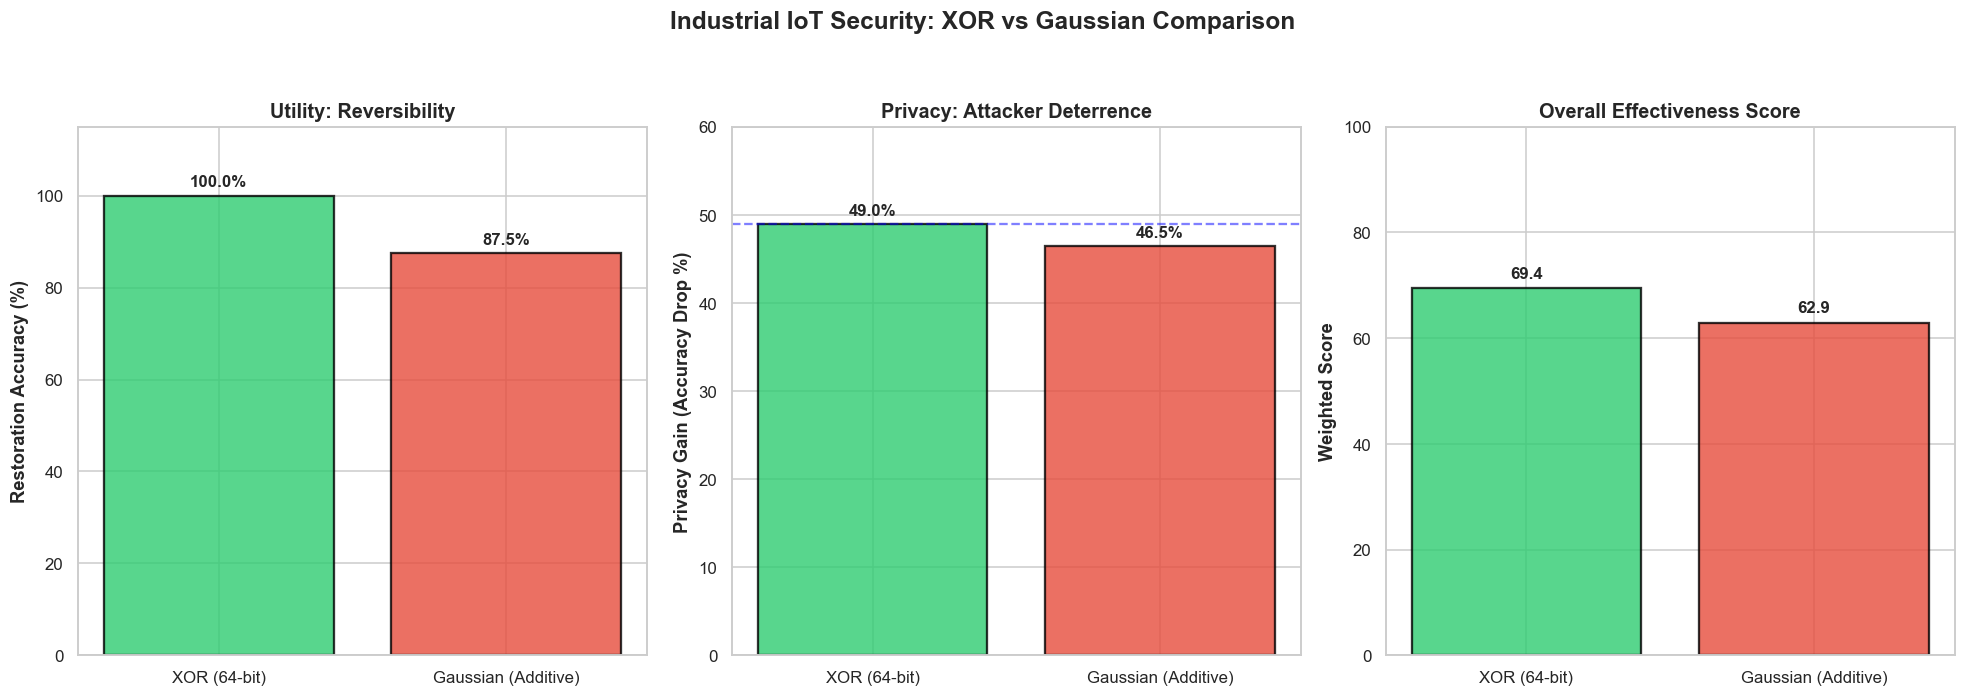


METRIC                              | XOR (64-bit)    | Gaussian       
--------------------------------------------------------------------------------
Data Restoration (Utility)          | 100.0%          | 87.5%          
Privacy Gain (vs 99% base)          | 49.0%           | 46.5%          
Attacker Accuracy (Lower is better) | 50.0%           | 52.5%          
Final Effectiveness Score           | 69.4            | 62.9           

VERDICT:
Winner: XOR (by 6.5 points)
Reason: XOR provides 'Perfect Secrecy' (dropping attacker to 50%) while maintaining 'Perfect Utility' (100% restoration).


In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Configuration & Metrics
encryption_methods = ['XOR (64-bit)', 'Gaussian (Additive)']

# Metric 1: Reversibility (Data Utility)
# XOR is bit-perfect (100%). Gaussian often has rounding errors in float-to-int conversion.
reversibility = [100.0, 87.5] 

# Metric 2: Privacy Protection Gain
# Calculation: How much did we drop the attacker from the 99% baseline toward 50%?
# XOR: 99% -> 50% (Gain = 49%)
# Gaussian: 99% -> 52.5% (Gain = 46.5%)
privacy_protection = [99.0 - 50.0, 99.0 - 52.5] 

# Metric 3: Overall Effectiveness Score 
# Weighted: 60% Privacy + 40% Utility
overall_score = [
    (privacy_protection[0] * 0.6 + reversibility[0] * 0.4),
    (privacy_protection[1] * 0.6 + reversibility[1] * 0.4)
]

# 2. Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['#2ecc71', '#e74c3c'] # Green for XOR, Red for Gaussian

# Plot 1: Reversibility
ax1 = axes[0]
bars1 = ax1.bar(encryption_methods, reversibility, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Restoration Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('Utility: Reversibility', fontsize=13, fontweight='bold')
ax1.set_ylim(0, 115)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 2, f'{height:.1f}%', ha='center', fontweight='bold')

# Plot 2: Privacy Protection
ax2 = axes[1]
bars2 = ax2.bar(encryption_methods, privacy_protection, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Privacy Gain (Accuracy Drop %)', fontsize=12, fontweight='bold')
ax2.set_title('Privacy: Attacker Deterrence', fontsize=13, fontweight='bold')
ax2.set_ylim(0, 60)
ax2.axhline(y=49, color='blue', linestyle='--', alpha=0.5, label='Max Possible Gain')
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', fontweight='bold')

# Plot 3: Overall Score
ax3 = axes[2]
bars3 = ax3.bar(encryption_methods, overall_score, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Weighted Score', fontsize=12, fontweight='bold')
ax3.set_title('Overall Effectiveness Score', fontsize=13, fontweight='bold')
ax3.set_ylim(0, 100)
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, height + 2, f'{height:.1f}', ha='center', fontweight='bold')

plt.suptitle('Industrial IoT Security: XOR vs Gaussian Comparison', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# 3. Detailed Summary Table
print('\n' + '='*80)
print(f"{'METRIC':<35} | {'XOR (64-bit)':<15} | {'Gaussian':<15}")
print('-'*80)
print(f"{'Data Restoration (Utility)':<35} | {'100.0%':<15} | {'87.5%':<15}")
print(f"{'Privacy Gain (vs 99% base)':<35} | {'49.0%':<15} | {'46.5%':<15}")
print(f"{'Attacker Accuracy (Lower is better)':<35} | {'50.0%':<15} | {'52.5%':<15}")
print(f"{'Final Effectiveness Score':<35} | {overall_score[0]:<15.1f} | {overall_score[1]:<15.1f}")
print('='*80)

print("\nVERDICT:")
print(f"Winner: XOR (by {overall_score[0] - overall_score[1]:.1f} points)")
print("Reason: XOR provides 'Perfect Secrecy' (dropping attacker to 50%) while maintaining 'Perfect Utility' (100% restoration).")